In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.integrate import quad
from scipy.stats import poisson
from scipy.special import factorial
from scipy.special import gammainc

from tracklab import ExperimentReader
# from configurations import create_fig, set_font_sizes, apply_general_styles, save_fig

# Save figure as svg
# path = Path('../../presentation/public/fig/')
path = Path('./')
# Make sure the directory exists
path.mkdir(parents=True, exist_ok=True)

## Plot Configs

In [2]:
"""
Script to set up the configurations for the plots.
"""
# Define font sizes
FONTSIZES = {
    'xxs': 4,
    'xs': 6,
    's': 8,
    'm': 10,
    'l': 12,
    'xl': 14,
    'xxl': 16
}

double_w = 7.2  # Width for double column
single_w = 3.5  # Width for single column

def set_font_sizes(conf='normal', factor=1, sizes=None):
    """
    Set font sizes for plots.
    """
    keys = ['font.size', 'axes.labelsize', 'axes.titlesize',
            'xtick.labelsize', 'ytick.labelsize',
            'legend.fontsize', 'figure.titlesize']
    
    if conf == 'normal':
        sizes = ['m', 'm', 'm', 's', 's', 's', 'l']
    elif conf == 'equal':
        sizes = ['m', 'm', 'm', 'm', 'm', 'm', 'm']
    elif conf == 'tight':
        sizes = ['s', 'm', 'm', 'xs', 'xs', 'xs', 'm']
    elif conf == 'custom':
        if sizes is None:
            raise ValueError("Must specify list of sizes (e.g., ['m', 'm', 'm', 's', 's', 's', 'l'])")
    
    for size, key in zip(sizes, keys):
        plt.rcParams[key] = FONTSIZES[size] * factor


def apply_general_styles():
    """
    Apply general plot styles.
    """
    plt.rcParams.update({
        'mathtext.fontset': 'cm',
        'font.family': 'STIXGeneral',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.dpi': 150,
        'text.usetex': False,
        'text.latex.preamble': r'\usepackage{amsmath,amssymb}'
    })


def create_fig(nrows=1,ncols=1,size='single',w=1.0,h=0.5,layout='constrained',sharex=True,sharey=None,w_ratios=None,h_ratios=None):
    width = single_w if size=='single' else double_w
    figsize = (w*width,h*width)
    fig , axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=figsize,layout=layout,sharex=sharex,sharey=sharey,gridspec_kw={'width_ratios': w_ratios, 'height_ratios': h_ratios})
    return fig , axes

apply_general_styles()
set_font_sizes(conf='tight')

# Poisson process probabilities

In [11]:
def true_norm(mu:int,V:int,rho:float)-> float:
    """
    Compute the normalization constant: sum_{l=1,...,mu/2} Poisson(l,mean)
    with mean = mu/(V*(1+rho))
    """
    mean = mu/(V*(1+rho))
    return np.sum(poisson.pmf(np.arange(1,mu//2+1),mean))

def apx_norm(mu:int,V:int,rho:float)-> float:
    """
    Compute the normalization constant: sum_{l>0} Poisson(l,mean)
    with mean = mu/(V*(1+rho))
    """
    mean = mu/(V*(1+rho))
    return 1-np.exp(-mean)

def true_poisson(l_vals:np.ndarray,mu:int,V:int,rho:float)-> np.ndarray:
    """
    Compute the true Poisson distribution: Poisson(l,mean)/norm
    with mean = mu/(V*(1+rho)) and norm = sum_{l=1,...,mu/2} Poisson(l,mean)
    """
    mean = mu/(V*(1+rho))
    norm = true_norm(mu,V,rho)
    prob = poisson.pmf(l_vals,mean)/norm
    prob[l_vals>mu//2] = 0
    prob[l_vals<1] = 0
    return prob

def apx_poisson(l_vals:np.ndarray,mu:int,V:int,rho:float)-> np.ndarray:
    """
    Compute the approximate Poisson distribution: Poisson(l,mean)/norm
    with mean = mu/(V*(1+rho)) and norm = sum_{l>0} Poisson(l,mean)
    """
    mean = mu/(V*(1+rho))
    norm = apx_norm(mu,V,rho)
    prob = poisson.pmf(l_vals,mean)/norm
    prob[l_vals<1] = 0
    return prob

mu=5, sum(true)=1.00000, sum(apx)=1.00000, difference=0.28849
mu=10, sum(true)=1.00000, sum(apx)=1.00000, difference=0.12565
mu=50, sum(true)=1.00000, sum(apx)=1.00000, difference=0.02050
mu=124, sum(true)=1.00000, sum(apx)=1.00000, difference=0.00103


Text(0, 0.5, '$P_\\ell^{(\\mu)}$')

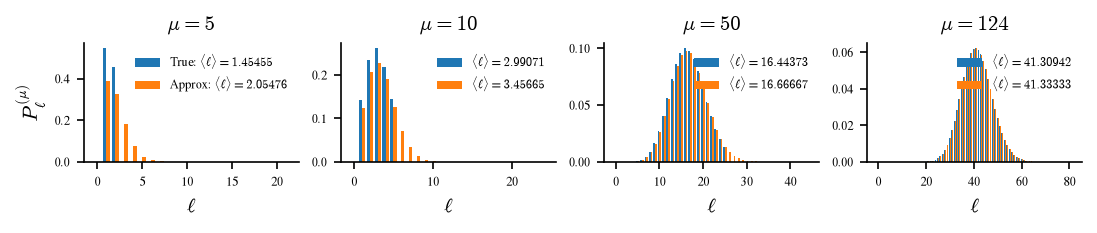

In [35]:
V = 2
rho = 0.5
L = 124

mu_vals = [5,10,50,L]

fig , axes = create_fig(ncols=len(mu_vals),h=0.2,size='double',sharex=False)

for i , ax in enumerate(axes):
    mu = mu_vals[i]
    ax.set_title(rf"$\mu={mu}$")
    l_vals = np.arange(0,mu//2+20)
    true = true_poisson(l_vals,mu,V,rho)
    apx = apx_poisson(l_vals,mu,V,rho)
    print(f"mu={mu}, sum(true)={np.sum(true):.5f}, sum(apx)={np.sum(apx):.5f}, difference={1.0-np.sum(apx[l_vals<=mu//2]):.5f}")
    mean_true = np.sum(l_vals*true)
    mean_apx = np.sum(l_vals*apx)
    lb_true = fr'True: $\langle \ell \rangle={mean_true:.5f}$' if i == 0 else fr'$\langle \ell \rangle={mean_true:.5f}$'
    lb_apx = fr'Approx: $\langle \ell \rangle={mean_apx:.5f}$' if i == 0 else fr'$\langle \ell \rangle={mean_apx:.5f}$'
    ax.bar(l_vals-0.2,true,width=0.4,label=lb_true,color='C0')
    ax.bar(l_vals+0.2,apx,width=0.4,label=lb_apx,color='C1')
    ax.set_xlabel(r"$\ell$")
    # ax.set_yscale('log')
    ax.legend(frameon=False)
axes[0].set_ylabel(r"$P_\ell^{(\mu)}$")


# l_vals = np.arange(0,L+1)
# true_norm = np.sum()

(1e-12, 1)

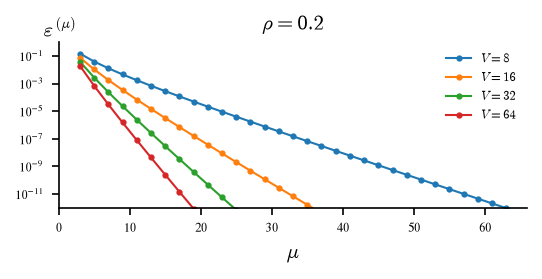

In [66]:
rho = 0.2
V_vals = [8,16,32,64]
mu_vals = np.arange(3,64,2)

fig , ax = create_fig()
for V in V_vals:
    diffs = []
    for mu in mu_vals:
        l_vals = np.arange(1,mu//2+1)
        P_apx = apx_poisson(l_vals,mu,V,rho)
        diffs.append(1.0-np.sum(P_apx))
    ax.plot(mu_vals,diffs,'.-',label=rf"$V={V}$",markersize=4,linewidth=1)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\varepsilon^{(\mu)}$",loc='top',rotation=0,labelpad=-30)
ax.set_yscale('log')
ax.legend(frameon=False)
ax.set_title(rf"$\rho={rho}$")
ax.set_ylim(1e-12,1)

# Comparison

In [3]:
def f(x:float) -> float:
    """
    Compute the function f(x) = 1-exp(-x)
    """
    return 1-np.exp(-x)

def Loss(h_on:float,V:int)-> float:
    """
    Compute the loss of the model as function of the on-target logit h_on:
    loss = log(1 + (V-1) * exp(-h_on))
    """
    return np.log1p((V-1)*np.exp(-h_on))

def logit_mean(z:float,Omega:float,beta:float,K:int,L:int)-> float:
    """
    Compute the mean of the on-target logit h_on as function of the input z:
    <h_on> = (beta K /L) Omega z
    """
    return beta*K*Omega*z/L


def S_limit(ell:np.ndarray, lam:float) -> np.ndarray:
    """L -> infinity limit: P[N_lam > ell]/lam."""
    return gammainc(np.asarray(ell) + 1.0, lam) / lam

def integrand_loss(x:float, Omega:float, beta:float, V:int, rho:float, L:int) -> float:
    """
    Integrand for the loss function for the global mean case.
    """
    lam = L/((1+rho)*V)
    K = int(V*rho)
    return f(x)*Loss(logit_mean(x/f(x), Omega, beta, K,L),V) / lam

def Loss_global_mean(Omega:np.ndarray, beta:float, V:int, rho:float, L:int) -> np.ndarray:
    """
    Compute the loss of the model as function of the on-target logit h_on:
    loss = log(1 + (V-1) * exp(-h_on))
    """
    lam = L/((1+rho)*V)
    return np.array([quad(integrand_loss, 0, lam, args=(Omega_i, beta, V, rho, L))[0] for Omega_i in Omega])

def Loss_modes_mean(Omega:np.ndarray, beta:float, V:int, rho:float, L:int) -> np.ndarray:
    """
    Compute the loss of the model as function of the on-target logit h_on:
    loss = log(1 + (V-1) * exp(-h_on))
    """
    lam = L/((1+rho)*V)
    K = int(V*rho)
    ell_vals = np.arange(1, L+1)
    return np.sum( S_limit(ell_vals[None,:],lam) * Loss(logit_mean(ell_vals[None,:],Omega[:,None],beta,K,L),V), axis=1)

def integrand_derivative(x:float, Omega:float, beta:float, V:int, rho:float, L:int) -> float:
    """
    Integrand for the derivative of the loss function for the global mean case.
    """
    lam = L/((1+rho)*V)
    K = int(V*rho)
    return x/(((V-1)+np.exp(logit_mean(x/f(x), Omega, beta, K,L)))*lam)

def derivative_global_mean(Omega:np.ndarray, beta:float, V:int, rho:float, L:int) -> np.ndarray:
    """
    Compute the derivative of the loss of the model as function of the on-target logit h_on:
    derivative = 1/((V-1)+exp(h_on))
    """
    lam = L/((1+rho)*V)
    return (2*V/lam)*np.array([quad(integrand_derivative, 0, lam, args=(Omega_i, beta, V, rho, L))[0] for Omega_i in Omega])

def derivative_modes_mean(Omega:np.ndarray, beta:float, V:int, rho:float, L:int) -> np.ndarray:
    """
    Compute the derivative of the loss of the model as function of the on-target logit h_on:
    derivative = 1/((V-1)+exp(h_on))
    """
    lam = L/((1+rho)*V)
    K = int(V*rho)
    ell_vals = np.arange(1, L+1)
    return (2*V/lam)*np.sum( S_limit(ell_vals[None,:],lam) * ell_vals[None,:]/((V-1)+np.exp(logit_mean(ell_vals[None,:],Omega[:,None],beta,K,L))), axis=1)

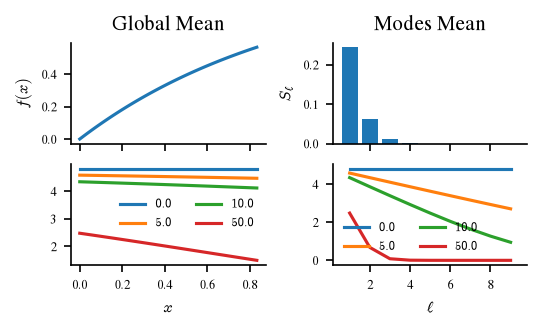

In [4]:
V = 124
rho = 0.2
beta = 0.25
L = 124
K = int(V*rho)
lam = L / ((1 + rho) * V)
Omega_vals = [0.0, 5.0, 10.0, 50.0]

x_vals = np.linspace(1e-3,lam,50)
ell_vals = np.arange(1,10)

fig , axes = create_fig(ncols=2,nrows=2,sharex='col',h=0.6)

# Global Mean
axs = axes[:,0]

ax = axs[0]
ax.set_title("Global Mean")

ax.set_ylabel(r"$f(x)$",fontsize=FONTSIZES['s'])
ax.plot(x_vals,f(x_vals))

ax = axs[1]
for Omega in Omega_vals:
    h_on = beta*K*Omega*x_vals/(L*f(x_vals))
    loss = Loss(h_on,V)
    ax.plot(x_vals,loss,label=rf"${Omega}$")

ax.set_xlabel(r"$x$",fontsize=FONTSIZES['s'])
ax.legend(frameon=False,ncols=2)


# Modes Mean
axs = axes[:,1]

ax = axs[0]
ax.set_title("Modes Mean")

ax.set_ylabel(r"$S_\ell$",fontsize=FONTSIZES['s'])
ax.bar(ell_vals,S_limit(ell_vals,lam))

ax = axs[1]
for Omega in Omega_vals:
    h_on = beta*K*Omega*ell_vals/L
    loss = Loss(h_on,V)
    ax.plot(ell_vals,loss,label=rf"${Omega}$")

ax.set_xlabel(r"$\ell$",fontsize=FONTSIZES['s'])
ax.legend(frameon=False,ncols=2)



C:\Users\crise\AppData\Local\Temp\ipykernel_18220\1869812597.py:76: RuntimeWarning: overflow encountered in exp
  return (2*V/lam)*np.sum( S_limit(ell_vals[None,:],lam) * ell_vals[None,:]/((V-1)+np.exp(logit_mean(ell_vals[None,:],Omega[:,None],beta,K,L))), axis=1)


Text(0, 0.5, '$\\partial_\\Omega \\mathcal{L}$')

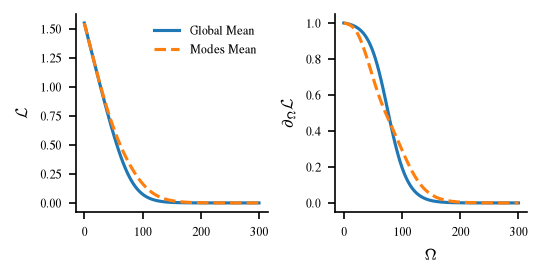

In [5]:
V = 124
beta = 0.25
rho = 0.2
L = 124

# beta , rho , L , V = 0.5 , 0.1 , 10, 1000


Omega_vals = np.linspace(0,300,100)


fig , axes = create_fig(ncols=2,h=0.5,size='single')

ax = axes[0]
loss_glob = Loss_global_mean(Omega_vals, beta, V, rho, L)
loss_modes = Loss_modes_mean(Omega_vals, beta, V, rho, L)

ax.plot(Omega_vals,loss_glob,label="Global Mean")
ax.plot(Omega_vals,loss_modes,label="Modes Mean",ls='--')
ax.set_ylabel(r"$\mathcal{L}$",fontsize=FONTSIZES['s'])
ax.legend(frameon=False)
# ax.set_yscale('log')

ax = axes[1]
deriv_glob = derivative_global_mean(Omega_vals, beta, V, rho, L)
deriv_modes = derivative_modes_mean(Omega_vals, beta, V, rho, L)

ax.plot(Omega_vals,deriv_glob,label="Global Mean")
ax.plot(Omega_vals,deriv_modes,label="Modes Mean",ls='--')
ax.set_xlabel(r"$\Omega$",fontsize=FONTSIZES['s'])
ax.set_ylabel(r"$\partial_\Omega \mathcal{L}$",fontsize=FONTSIZES['s'])


In [25]:
def ode_global(z,t,eta_0, beta, V, rho, L):
    """
    Compute dz/dt which is the effective equation for the evolution of the order parameters
    in the global mean case.
    """
    K = int(V*rho)
    alpha = eta_0/(rho*np.sqrt(rho*(1-rho)))
    L0_prime = 0.5*beta*rho**2/(1+rho)**2

    Omega = (1/K)*np.sqrt(V**3/(L*K*(V-K))) * z**3
    deriv = derivative_global_mean(Omega, beta, V, rho, L)
    return alpha * L0_prime*deriv *z**2/(np.sqrt(V**3*L))

def ode_modes(z,t,eta_0, beta, V, rho, L):
    """
    Compute dz/dt which is the effective equation for the evolution of the order parameters
    in the global mean case.
    """
    K = int(V*rho)
    alpha = eta_0/(rho*np.sqrt(rho*(1-rho)))
    L0_prime = 0.5*beta*rho**2/(1+rho)**2

    Omega = (1/K)*np.sqrt(V**3/(L*K*(V-K))) * z**3
    deriv = derivative_modes_mean(Omega, beta, V, rho, L)
    return alpha * L0_prime* deriv *z**2/(np.sqrt(V**3*L))


C:\Users\crise\AppData\Local\Temp\ipykernel_18220\1869812597.py:76: RuntimeWarning: overflow encountered in exp
  return (2*V/lam)*np.sum( S_limit(ell_vals[None,:],lam) * ell_vals[None,:]/((V-1)+np.exp(logit_mean(ell_vals[None,:],Omega[:,None],beta,K,L))), axis=1)


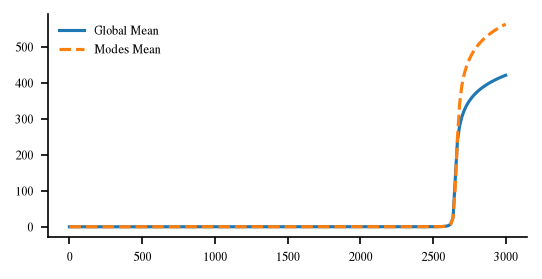

In [30]:
V = 128
beta = 0.25
rho = 0.2
L = 328
bs = 512
eta_0 = 5 * bs

c_omega = (1/K)*np.sqrt(V**3/(L*K*(V-K)))


z_0 = 1/np.sqrt(V)
ode_times = np.linspace(0,3000,200)

# Global Mean Case
z_global = odeint(ode_global, z_0, ode_times, args=(eta_0, beta, V, rho, L))[:,0]
# Modes Mean Case
z_modes = odeint(ode_modes, z_0, ode_times, args=(eta_0, beta, V, rho, L))[:,0]


fig , axes = create_fig(ncols=1)

ax = axes
ax.plot(ode_times,c_omega*z_global**3,label="Global Mean")
ax.plot(ode_times,c_omega*z_modes**3,label="Modes Mean",ls='--')

ax.legend(frameon=False)


# Constant in sweep experiments

Text(0, 0.5, '$\\bar\\omega$')

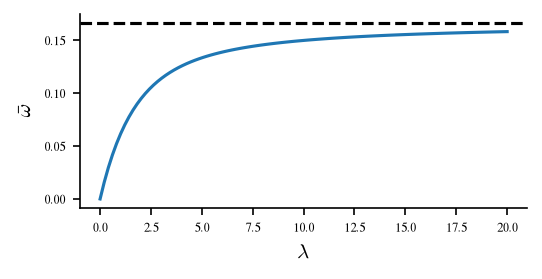

In [7]:
omega_bar = lambda rho,lam: (rho/(1+rho)) * (1- (1-np.exp(-lam)) / lam)

rho = 0.2

lmb_vals = np.linspace(1e-3, 20, 100)
solv_frac = omega_bar(rho,lmb_vals)

fig , ax = create_fig()

ax.plot(lmb_vals,solv_frac)
ax.axhline(y=rho/(1+rho),color='k',ls='--',label=r"$\rho/(1+\rho)$")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\bar\omega$")

V=64, min(bs)=6, max(bs)=291
V=128, min(bs)=6, max(bs)=514
V=256, min(bs)=8, max(bs)=963
V=512, min(bs)=11, max(bs)=1863
V=1024, min(bs)=18, max(bs)=3662
V=--, min(bs)=5, max(bs)=93
V=64, min(ntokens)=6486, max(ntokens)=18661
V=128, min(ntokens)=7057, max(ntokens)=32934
V=256, min(ntokens)=8442, max(ntokens)=61668
V=512, min(ntokens)=11688, max(ntokens)=119234
V=1024, min(ntokens)=18661, max(ntokens)=234417
V=--, min(ntokens)=6000, max(ntokens)=6000


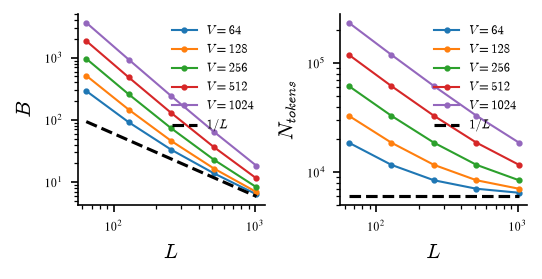

In [34]:
V_vals = np.array([64,128,256,512,1024])
L_vals = np.array([64,128,256,512,1024])

fig , axes = create_fig(ncols=2)

ax = axes[0]
c = 1000

for V in V_vals:
    lam_vals = L_vals/((1+rho)*V)
    frac = omega_bar(rho,lam_vals)
    bs = c/(frac*L_vals)
    ax.plot(L_vals,bs,label=rf"$V={V}$",ls='-',marker='.',markersize=4,linewidth=1)
    print(f"V={V}, min(bs)={int(np.min(bs))}, max(bs)={int(np.max(bs))}")

bs = c*(1+rho)/(rho*L_vals)
ax.plot(L_vals,bs,label=r"$1/L$",ls='--',color='k')
print(f"V=--, min(bs)={int(np.min(bs))}, max(bs)={int(np.max(bs))}")


ax.set_xlabel(r"$L$")
ax.set_ylabel(r"$B$")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(frameon=False)


ax = axes[1]
c = 1000

for V in V_vals:
    lam_vals = L_vals/((1+rho)*V)
    frac = omega_bar(rho,lam_vals)
    ntokens = c/(frac)
    ax.plot(L_vals,ntokens,label=rf"$V={V}$",ls='-',marker='.',markersize=4,linewidth=1)
    print(f"V={V}, min(ntokens)={int(np.min(ntokens))}, max(ntokens)={int(np.max(ntokens))}")
ntokens = c*(1+rho)/(rho) * np.ones_like(L_vals)
ax.plot(L_vals,ntokens,label=r"$1/L$",ls='--',color='k')
print(f"V=--, min(ntokens)={int(np.min(ntokens))}, max(ntokens)={int(np.max(ntokens))}")


ax.set_xlabel(r"$L$")
ax.set_ylabel(r"$N_{tokens}$")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(frameon=False)

In [32]:
L = 512
bs = 512

ntokens = L*bs
print(f"L={L}, bs={bs}, ntokens={ntokens}")

L=512, bs=512, ntokens=262144


In [41]:
beta = 0.25
rho = 0.2
eta_0 = 2500

V = 124
L = 124

L0_prime = 0.5*beta*rho**2/(1+rho)**2

time_constant = rho*np.sqrt(rho*(1-rho)) / (eta_0*L0_prime)
print(f"time_constant={time_constant:.5f}")

time = time_constant * V**2 * np.sqrt(L)
print(f"time={time:.5f}")

time_constant=0.00922
time=1577.96250
